[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Lab_Notebooks/chapter_05_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 5 — Resampling Methods
## Lab: validation set, k-fold CV, LOOCV, the bootstrap

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal of this lab.** Estimate test error of a regression in three ways and use the bootstrap to put a standard error on a regression coefficient.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and (once the repo is on GitHub and `GITHUB_RAW` is set) downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import warnings; warnings.filterwarnings('ignore')  # keep output clean; remove to see all warnings
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


## 1. The Auto data set


In [2]:
Auto = load('Auto', na_values='?').dropna().reset_index(drop=True)
X = Auto[['horsepower']].values
y = Auto['mpg'].values
Auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


## 2. Validation set approach


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5, random_state=1)
for d in range(1, 6):
    m = make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).fit(Xtr, ytr)
    print(f'degree {d}: validation MSE = {mean_squared_error(yte, m.predict(Xte)):.3f}')


degree 1: validation MSE = 24.802
degree 2: validation MSE = 18.848
degree 3: validation MSE = 18.805
degree 4: validation MSE = 18.712
degree 5: validation MSE = 18.324


## 3. k-fold cross-validation


In [4]:
from sklearn.model_selection import KFold, cross_val_score
cv = KFold(n_splits=10, shuffle=True, random_state=0)
for d in range(1, 11):
    m = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    score = -cross_val_score(m, X, y, cv=cv,
                              scoring='neg_mean_squared_error').mean()
    print(f'degree {d}: CV MSE = {score:.3f}')


degree 1: CV MSE = 24.208
degree 2: CV MSE = 19.185
degree 3: CV MSE = 19.276
degree 4: CV MSE = 19.478
degree 5: CV MSE = 19.137
degree 6: CV MSE = 19.255
degree 7: CV MSE = 19.150
degree 8: CV MSE = 18.962
degree 9: CV MSE = 19.099
degree 10: CV MSE = 19.866


## 4. LOOCV (leave-one-out)


In [5]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
for d in range(1, 6):
    m = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    score = -cross_val_score(m, X, y, cv=loo,
                              scoring='neg_mean_squared_error').mean()
    print(f'degree {d}: LOOCV MSE = {score:.3f}')


degree 1: LOOCV MSE = 24.232


degree 2: LOOCV MSE = 19.248


degree 3: LOOCV MSE = 19.335


degree 4: LOOCV MSE = 19.424


degree 5: LOOCV MSE = 19.033


Note how 10-fold and LOOCV give similar pictures, but LOOCV runs $n = 392$ fits.


## 5. The bootstrap
Estimate the SE of the slope of `mpg ~ horsepower`.


In [6]:
from sklearn.linear_model import LinearRegression
B = 1000
boots = np.empty(B)
n = len(X)
for b in range(B):
    idx = rng.integers(0, n, size=n)
    boots[b] = LinearRegression().fit(X[idx], y[idx]).coef_[0]
print('bootstrap SE      :', boots.std(ddof=1).round(4))
print('bootstrap 95% CI  :', np.quantile(boots, [0.025, 0.975]).round(4))
import statsmodels.api as sm
Xc = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
print('OLS SE            :', round(ols.bse[1], 4))
print('OLS 95% CI        :', ols.conf_int().iloc[1].round(4).tolist()
    if hasattr(ols.conf_int(), 'iloc') else ols.conf_int()[1].round(4).tolist())


bootstrap SE      : 0.0077
bootstrap 95% CI  : [-0.1754 -0.1439]


OLS SE            : 0.0064
OLS 95% CI        : [-0.1705, -0.1452]


Plot the bootstrap distribution.


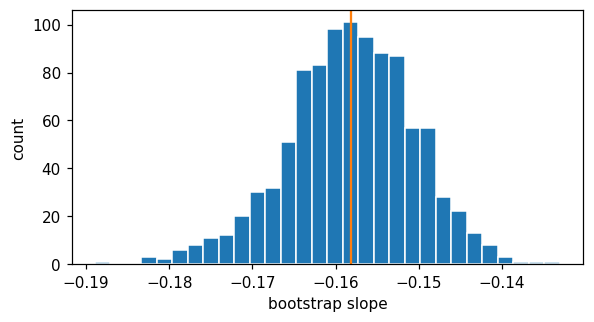

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(boots, bins=30, edgecolor='white')
ax.axvline(boots.mean(), color='C1')
ax.set(xlabel='bootstrap slope', ylabel='count'); plt.show()


## Lecture exercises — worked Python solutions

The cells below mirror the **[Python]-tagged exercises** from the Chapter 5 lecture slides, with fully worked, runnable solutions and the expected numeric answers (stored as inline comments). Each solution uses the `load()` helper from the setup cell, so it runs locally or on Colab with no hard-coded paths.

### Exercise 5.6 — Bootstrap SE of the Portfolio $\alpha$

The `Portfolio` data has two return series `X` and `Y`. The minimum-variance allocation to asset `X` is
$$\hat\alpha=\frac{\hat\sigma_Y^2-\hat\sigma_{XY}}{\hat\sigma_X^2+\hat\sigma_Y^2-2\hat\sigma_{XY}}.$$
Compute $\hat\alpha$ on the full sample and estimate its standard error with $B=1000$ bootstrap resamples (rows drawn *with replacement*, keeping each $(X_i,Y_i)$ pair together).

In [8]:
# Exercise 5.6 -- bootstrap standard error of the Portfolio allocation alpha.
# alpha is a nonlinear ratio of variances/covariance, so no closed-form SE
# exists -> the bootstrap is the natural tool (ISLP Section 5.2).
Port   = load('Portfolio')                       # columns X, Y (asset returns)
Xp, Yp = Port['X'].values, Port['Y'].values

def alpha_hat(x, y):                             # minimum-variance allocation
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)    # sample variances
    sxy    = np.cov(x, y, ddof=1)[0, 1]              # sample covariance
    return (sy - sxy) / (sx + sy - 2 * sxy)

rng  = np.random.default_rng(0)                  # reproducible (matches slide)
n, B = len(Xp), 1000                             # B bootstrap replications
reps = np.empty(B)
for b in range(B):
    idx     = rng.integers(0, n, size=n)         # ONE shared index -> keep pairs
    reps[b] = alpha_hat(Xp[idx], Yp[idx])        # recompute alpha on the resample

print('alpha_hat    :', round(alpha_hat(Xp, Yp), 4))   # 0.5758  (~0.58)
print('bootstrap SE :', round(reps.std(ddof=1), 4))    # 0.0912  (~0.09)

alpha_hat    : 0.5758
bootstrap SE : 0.0912


**Interpretation.** The point estimate is $\hat\alpha\approx0.58$ with a bootstrap standard error of $\approx0.09$, matching ISLP Section 5.2: across resamples the estimated optimal allocation to asset `X` varies by about $\pm0.09$ — an uncertainty statement that no closed-form formula supplies for $\alpha$. *Common mistake:* drawing separate index vectors for `X` and `Y`, which destroys the $X$–$Y$ covariance the statistic depends on; one shared `idx` keeps the pairs intact.

### Extended Exercise 5.2 — Bootstrap SE: statistic *and* coefficient

Extend Exercise 5.6 in two directions: (1) report a 95% *percentile* confidence interval for the Portfolio $\hat\alpha$ alongside its bootstrap SE; and (2) bootstrap the OLS slope of `mpg` on `horsepower` in the `Auto` data and compare the bootstrap SE with the textbook (formula-based) OLS standard error.

In [9]:
# Extended Exercise 5.2 -- (1) percentile CI for alpha, (2) bootstrap the OLS
# slope and compare it with the formula-based SE.  Reuses alpha_hat, Xp, Yp, n
# defined in Exercise 5.6 above.
import statsmodels.api as sm

# --- (1) Portfolio alpha: bootstrap SE + 95% percentile interval ----------
rng  = np.random.default_rng(0)                  # reproducible (matches slide)
reps = np.empty(1000)
for b in range(1000):
    idx     = rng.integers(0, n, size=n)         # one shared index -> keep pairs
    reps[b] = alpha_hat(Xp[idx], Yp[idx])
print('alpha_hat        :', round(alpha_hat(Xp, Yp), 4))                    # 0.5758
print('alpha SE         :', round(reps.std(ddof=1), 4))                     # 0.0912
print('alpha 95% pctile :', np.round(np.quantile(reps, [.025, .975]), 3))  # [0.413 0.77]

# --- (2) Auto: bootstrap OLS slope vs formula-based SE --------------------
Auto = load('Auto', na_values='?').dropna()
hp   = Auto['horsepower'].values.astype(float)   # predictor
mpg  = Auto['mpg'].values                        # response
ols  = sm.OLS(mpg, sm.add_constant(hp)).fit()    # single fit -> formula SE
print('OLS slope        :', round(ols.params[1], 4))    # -0.1578
print('OLS formula SE   :', round(ols.bse[1], 5))       #  0.00645

rng    = np.random.default_rng(0)
m      = len(hp)
slopes = np.empty(1000)
for b in range(1000):
    idx       = rng.integers(0, m, size=m)       # resample rows with replacement
    slopes[b] = sm.OLS(mpg[idx], sm.add_constant(hp[idx])).fit().params[1]
print('bootstrap SE     :', round(slopes.std(ddof=1), 5))                     # 0.00746
print('bootstrap 95% CI :', np.round(np.quantile(slopes, [.025, .975]), 4))   # [-0.1732 -0.1443]

alpha_hat        : 0.5758
alpha SE         : 0.0912
alpha 95% pctile : [0.413 0.77 ]
OLS slope        : -0.1578
OLS formula SE   : 0.00645
bootstrap SE     : 0.00746
bootstrap 95% CI : [-0.1732 -0.1443]


**Interpretation.** The Portfolio 95% percentile interval $\approx[0.41,\,0.77]$ turns the point estimate into an honest uncertainty range. For the `Auto` slope, the bootstrap SE ($\approx0.0075$) is close to the OLS formula SE ($\approx0.0064$), which *validates* the bootstrap. Where they differ the bootstrap is often more trustworthy: the formula SE assumes a correctly specified linear model with constant-variance errors, whereas the bootstrap assumes neither and picks up the mild nonlinearity/heteroscedasticity in `Auto` — hence the slightly larger bootstrap SE.

## 6. Exercises
1. Bootstrap the *intercept* and compare to the OLS SE.
2. Repeat the polynomial CV using `weight` instead of `horsepower`. Which degree wins?
3. Write a function `boot_stat(data, stat, B=1000)` that returns $B$ bootstrap replications of `stat(data)`.
4. Use the bootstrap to estimate the SE of the *minimum* of a Gaussian sample. Compare with the parametric formula.
